# Multi-Layer Perceptron in `keras`

In this series of lab sessions, you will use a Python library called `keras` (that is in fact embedded inside a larger library called `tensorflow`, but we will not discuss `tensorflow` in this course).
You should visit [`keras` webpage](https://www.tensorflow.org/guide/keras/overview) to get access to more information about this library, including a comprehensive documentation.

## The `Sequential` model in `keras`

This library offers two ways to define neural network models. 
We will start with the `Sequential` class of `keras` models.
Below is an example of how to define a `Sequential` model:

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer

2023-01-09 15:18:37.227308: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


**1. Define layers, and add them one by one to the model**


In [ ]:
input_layer = InputLayer(input_shape=(24,))
hidden_layer1 = Dense(units=12, activation="relu")
hidden_layer2 = Dense(units=12, activation="sigmoid")
#[...]
output_layer = Dense(units=3, activation="linear")

model = Sequential([
    input_layer,
    hidden_layer1,
    hidden_layer2,
    # ...
    output_layer
])

**2. Pick an optimization algorithm (optimizer) and a loss function to be optimized**

Usual loss functions are:
* `"mse"` for regression,
* `"categorical_crossentropy"` for multiclass classification (when the `y` array fed to `fit` is of shape $(n, n_\text{classes})$)
* `"binary_crossentropy"` for binary classification (when the model is fed with `y` array of shape $(n, 1)$)

One can also specify additional metrics to be printed during training (correct classification rate here).

In [ ]:
model.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

**3. Fit the model**

NB: do not try to execute the following line of code: variables `X_train` and `y_train` do not exist yet!

In [ ]:
#model.fit(X_train, y_train, verbose=2, epochs=10, batch_size=200)

## Data pre-processing

Have a look at the `prepare_mnist` and `prepare_boston` functions defined below.

**Question #1.** What do these functions do? What are the shapes of returned arrays? Does the returned data correpond to classification or regression problems?

In [2]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.datasets import mnist, boston_housing
from tensorflow.keras.utils import to_categorical

def prepare_mnist():
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    x_train = x_train.reshape((x_train.shape[0], -1))
    x_test = x_test.reshape((x_test.shape[0], -1))
    scaler = MinMaxScaler()
    scaler.fit(x_train)
    x_train = scaler.transform(x_train)
    x_test = scaler.transform(x_test)
    y_train = to_categorical(y_train)
    y_test = to_categorical(y_test)
    return x_train, x_test, y_train, y_test


def prepare_boston():
    (x_train, y_train), (x_test, y_test) = boston_housing.load_data()
    scaler_x = MinMaxScaler()
    scaler_x.fit(x_train)
    x_train = scaler_x.transform(x_train)
    x_test = scaler_x.transform(x_test)
    scaler_y = MinMaxScaler()
    scaler_y.fit(y_train.reshape((-1, 1)))
    y_train = scaler_y.transform(y_train.reshape((-1, 1)))
    y_test = scaler_y.transform(y_test.reshape((-1, 1)))
    return x_train, x_test, y_train, y_test
  
x_train, x_test, y_train, y_test = prepare_mnist()

In [4]:
x_train, x_test, y_train, y_test = prepare_boston()
print(x_train.shape, y_train.shape)

(404, 13) (404, 1)


## Building your first models

In the following, when fitting models, restrict the training to 10 epochs (which is not realistic, but training for more epochs takes time...)

**Question #2.** Following the guidelines provided above, implement a linear regression model for the `boston` dataset that would optimize on a least squares objective using Stochastic Gradient Descent and fit your model to the corresponding training data.

In [5]:
model = Sequential([
    InputLayer(input_shape=(13, )),
    Dense(units=1, activation="linear")
])
model.compile(loss="mse", optimizer="sgd"),
model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10, batch_size=100)

2023-01-09 15:27:28.006307: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/10
5/5 [==============================] - 1s 125ms/step - loss: 0.1446 - val_loss: 0.1537
Epoch 2/10
5/5 [==============================] - 0s 20ms/step - loss: 0.1421 - val_loss: 0.1516
Epoch 3/10
5/5 [==============================] - 0s 39ms/step - loss: 0.1396 - val_loss: 0.1502
Epoch 4/10
5/5 [==============================] - 0s 45ms/step - loss: 0.1375 - val_loss: 0.1487
Epoch 5/10
5/5 [==============================] - 0s 26ms/step - loss: 0.1360 - val_loss: 0.1464
Epoch 6/10
5/5 [==============================] - 0s 26ms/step - loss: 0.1349 - val_loss: 0.1451
Epoch 7/10
5/5 [==============================] - 0s 16ms/step - loss: 0.1323 - val_loss: 0.1453
Epoch 8/10
5/5 [==============================] - 0s 10ms/step - loss: 0.1311 - val_loss: 0.1439
Epoch 9/10
5/5 [==============================] - 0s 12ms/step - loss: 0.1297 - val_loss: 0.1431
Epoch 10/10
5/5 [==============================] - 0s 13ms/step - loss: 0.1286 - val_loss: 0.1410


**Question #3.** Similarly, define a logistic regression model for the `mnist` dataset and print its training accuracy during training.

In [6]:
x_train, x_test, y_train, y_test = prepare_mnist()
print(x_train.shape, y_train.shape)

(60000, 784) (60000, 10)


In [9]:
model = Sequential([
    InputLayer(input_shape=(784,)),
    Dense(units=10, activation="softmax")
])

model.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])
model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10, batch_size=100)

Epoch 1/2
600/600 [==============================] - 2s 4ms/step - loss: 1.1689 - val_loss: 0.7270
Epoch 2/2
600/600 [==============================] - 1s 2ms/step - loss: 0.6497 - val_loss: 0.5548


**Question #4.** Compare performance (in terms of training accuracy, we will come back to better ways to compare models afterwards) of this logistic regression model with that of a neural network with respectively 1, 2, and 3 hidden layers of 128 neurons each.
You will use the `"relu"` activation function for hidden layers.

In [22]:
l = [InputLayer(input_shape=(784,))]
for _ in range(3):
    l.append(Dense(units=128, activation="relu"))
l.append(Dense(units=10, activation="softmax"))

model = Sequential(l)

model.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])
# model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10, batch_size=100)
model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_30 (Dense)            (None, 128)               100480    
                                                                 
 dense_31 (Dense)            (None, 128)               16512     
                                                                 
 dense_32 (Dense)            (None, 128)               16512     
                                                                 
 dense_33 (Dense)            (None, 10)                1290      
                                                                 
Total params: 134,794
Trainable params: 134,794
Non-trainable params: 0
_________________________________________________________________


**Question #5.** `keras` models offer a `count_params()` method to get the number of parameters to be learned in the model. Use this facility to get the number of parameters of your 3-hidden-layer model.

In [17]:
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_18 (Dense)            (None, 128)               100480    
                                                                 
 dense_19 (Dense)            (None, 128)               16512     
                                                                 
 dense_20 (Dense)            (None, 128)               16512     
                                                                 
 dense_21 (Dense)            (None, 10)                1290      
                                                                 
Total params: 134,794
Trainable params: 134,794
Non-trainable params: 0
_________________________________________________________________


## A better way to compare models

Comparing models based on training accuracy (resp. loss) is a "great" way to overfit your model to the training data.
A better way to compare models is to use hold out data (aka validation set).

To do so, `keras` allows to pass, at `fit` time, a fraction of the training data to be used as validation set. Have a look [there](https://www.tensorflow.org/guide/keras/train_and_evaluate#automatically_setting_apart_a_validation_holdout_set) for more details about how validation samples are selected.

**Question #6.** Repeat model comparisons above (relying on validation scores) using 30% of training data as validation set.

In [31]:
model = Sequential([
    InputLayer(input_shape=(784,)),
    Dense(units=128, activation="relu"),
    Dense(units=128, activation="relu"),
    Dense(units=10, activation="softmax")
])

model.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])
h = model.fit(x_train, y_train, validation_split=0.3, epochs=20, batch_size=100)
print(h.history)

Epoch 1/20
420/420 [==============================] - 5s 6ms/step - loss: 1.4476 - accuracy: 0.6320 - val_loss: 0.7366 - val_accuracy: 0.8271
Epoch 2/20
420/420 [==============================] - 2s 6ms/step - loss: 0.5743 - accuracy: 0.8571 - val_loss: 0.4556 - val_accuracy: 0.8812
Epoch 3/20
420/420 [==============================] - 3s 6ms/step - loss: 0.4231 - accuracy: 0.8863 - val_loss: 0.3799 - val_accuracy: 0.8938
Epoch 4/20
420/420 [==============================] - 2s 4ms/step - loss: 0.3663 - accuracy: 0.8976 - val_loss: 0.3430 - val_accuracy: 0.9024
Epoch 5/20
420/420 [==============================] - 1s 3ms/step - loss: 0.3341 - accuracy: 0.9059 - val_loss: 0.3190 - val_accuracy: 0.9073
Epoch 6/20
420/420 [==============================] - 2s 4ms/step - loss: 0.3113 - accuracy: 0.9117 - val_loss: 0.3004 - val_accuracy: 0.9117
Epoch 7/20
420/420 [==============================] - 1s 3ms/step - loss: 0.2932 - accuracy: 0.9169 - val_loss: 0.2854 - val_accuracy: 0.9176
Epoch 

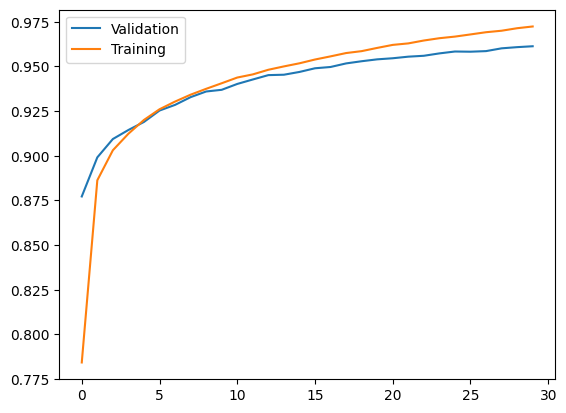

In [29]:
import matplotlib.pyplot as plt

plt.plot(h.history["val_accuracy"], label="Validation")
plt.plot(h.history["accuracy"], label="Training")
plt.legend();

## Optimizers and learning rate

**Question #7.** Change the optimizer used for your model. Use an optimizer with momentum and adaptive learning rate.

In [30]:
model = Sequential([
    InputLayer(input_shape=(784,)),
    Dense(units=128, activation="relu"),
    Dense(units=128, activation="relu"),
    Dense(units=10, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
h = model.fit(x_train, y_train, validation_split=0.3, epochs=20, batch_size=100)

Epoch 1/20
420/420 [==============================] - 3s 6ms/step - loss: 0.3508 - accuracy: 0.8999 - val_loss: 0.1788 - val_accuracy: 0.9502
Epoch 2/20
420/420 [==============================] - 2s 4ms/step - loss: 0.1371 - accuracy: 0.9588 - val_loss: 0.1384 - val_accuracy: 0.9599
Epoch 3/20
420/420 [==============================] - 2s 4ms/step - loss: 0.0923 - accuracy: 0.9718 - val_loss: 0.1195 - val_accuracy: 0.9648
Epoch 4/20
420/420 [==============================] - 2s 4ms/step - loss: 0.0697 - accuracy: 0.9795 - val_loss: 0.1046 - val_accuracy: 0.9687
Epoch 5/20
420/420 [==============================] - 2s 4ms/step - loss: 0.0533 - accuracy: 0.9837 - val_loss: 0.1057 - val_accuracy: 0.9685
Epoch 6/20
420/420 [==============================] - 2s 4ms/step - loss: 0.0414 - accuracy: 0.9878 - val_loss: 0.1067 - val_accuracy: 0.9697
Epoch 7/20
420/420 [==============================] - 2s 4ms/step - loss: 0.0319 - accuracy: 0.9903 - val_loss: 0.1112 - val_accuracy: 0.9699
Epoch 

**Question #8.** Using [the docs](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers), vary the learning rate of your optimizer from a very low value to a much larger one so as to show evidence of:
* instability when the learning rate is too large;
* slow convergence when the learning rate is too low.

In [38]:
from tensorflow.keras.optimizers import Adam, SGD

model = Sequential([
    InputLayer(input_shape=(784,)),
    Dense(units=128, activation="relu"),
    Dense(units=128, activation="relu"),
    Dense(units=10, activation="softmax")
])

model.compile(optimizer=SGD(learning_rate=1000.), loss="categorical_crossentropy", metrics=["accuracy"])
h = model.fit(x_train, y_train, validation_split=0.3, epochs=5, batch_size=100)

Epoch 1/5
420/420 [==============================] - 2s 4ms/step - loss: 5005575577044325329561842899484672.0000 - accuracy: 0.0974 - val_loss: 301.9274 - val_accuracy: 0.0966
Epoch 2/5
420/420 [==============================] - 1s 3ms/step - loss: 449.1268 - accuracy: 0.1024 - val_loss: 335.6313 - val_accuracy: 0.1079
Epoch 3/5
420/420 [==============================] - 1s 3ms/step - loss: 449.8318 - accuracy: 0.1015 - val_loss: 293.8632 - val_accuracy: 0.1035
Epoch 4/5
420/420 [==============================] - 2s 5ms/step - loss: 450.9258 - accuracy: 0.0996 - val_loss: 559.6113 - val_accuracy: 0.0989
Epoch 5/5
420/420 [==============================] - 2s 5ms/step - loss: 445.1931 - accuracy: 0.1024 - val_loss: 571.8767 - val_accuracy: 0.0968


## Callbacks

Callbacks are tools that, in `keras`, allow one to intervene during the training process of a model. 
Callbacks can be used to take actions (_ie._ save intermediate model, stop optimization if overfitting occurs, _etc._).

A first callback one can play with is the one returned by any call to `fit` on a `keras` model.
This callback is an object with an `.history` attribute in the form of a Python dictionnary whose keys are the metrics recorded during training. Each of these keys links to an array containing the consecutive values of the considered quantity (one value per epoch).

**Question #9.** Plot correct classification rates on both training and validation sets.

Epoch 1/10
420/420 [==============================] - 2s 4ms/step - loss: 0.3550 - accuracy: 0.8998 - val_loss: 0.1835 - val_accuracy: 0.9458
Epoch 2/10
420/420 [==============================] - 2s 4ms/step - loss: 0.1397 - accuracy: 0.9583 - val_loss: 0.1363 - val_accuracy: 0.9596
Epoch 3/10
420/420 [==============================] - 1s 4ms/step - loss: 0.0970 - accuracy: 0.9708 - val_loss: 0.1326 - val_accuracy: 0.9628
Epoch 4/10
420/420 [==============================] - 2s 4ms/step - loss: 0.0724 - accuracy: 0.9787 - val_loss: 0.1081 - val_accuracy: 0.9683
Epoch 5/10
420/420 [==============================] - 2s 4ms/step - loss: 0.0561 - accuracy: 0.9828 - val_loss: 0.1093 - val_accuracy: 0.9673
Epoch 6/10
420/420 [==============================] - 2s 4ms/step - loss: 0.0426 - accuracy: 0.9873 - val_loss: 0.1025 - val_accuracy: 0.9692
Epoch 7/10
420/420 [==============================] - 1s 3ms/step - loss: 0.0356 - accuracy: 0.9888 - val_loss: 0.1264 - val_accuracy: 0.9659
Epoch 

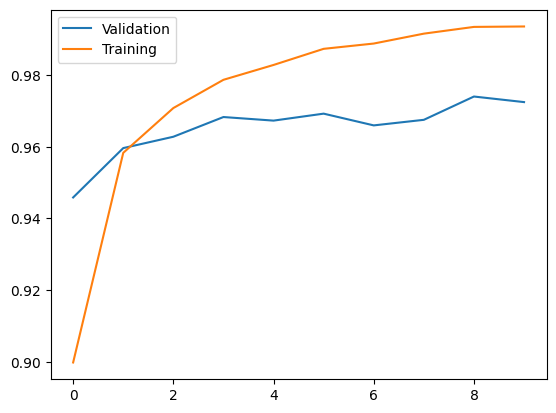

In [40]:
model = Sequential([
    InputLayer(input_shape=(784,)),
    Dense(units=128, activation="relu"),
    Dense(units=128, activation="relu"),
    Dense(units=10, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
h = model.fit(x_train, y_train, validation_split=0.3, epochs=10, batch_size=100)

plt.plot(h.history["val_accuracy"], label="Validation")
plt.plot(h.history["accuracy"], label="Training")
plt.legend();

Setting up other callbacks must be explicit. This is done by passing a list of callbacks to the `fit` method.

When training a model is long, one can wish to record intermediate models (in case of a crash during training, or just for cases when intermediate models were performing better than the final one).
The [`ModelCheckpoint`](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint) callback is designed for that purpose.

**Question #10.** Set up recording of intermediate models every epoch. Save the models into a dedicated file `model.hdf5` on your Deepnote project. Only record models if validation loss is lower than for all previous models.

In [41]:
from tensorflow.keras.callbacks import ModelCheckpoint

model = Sequential([
    InputLayer(input_shape=(784,)),
    Dense(units=128, activation="relu"),
    Dense(units=128, activation="relu"),
    Dense(units=10, activation="softmax")
])

cb1 = ModelCheckpoint(
    filepath="model.hdf5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.fit(x_train, y_train, validation_split=0.3, epochs=10, batch_size=100, callbacks=[cb1])

Epoch 1/10
410/420 [============================>.] - ETA: 0s - loss: 0.3524 - accuracy: 0.8999
Epoch 1: val_loss improved from inf to 0.17033, saving model to model.hdf5
420/420 [==============================] - 3s 6ms/step - loss: 0.3485 - accuracy: 0.9009 - val_loss: 0.1703 - val_accuracy: 0.9489
Epoch 2/10
405/420 [===========================>..] - ETA: 0s - loss: 0.1423 - accuracy: 0.9578
Epoch 2: val_loss improved from 0.17033 to 0.13690, saving model to model.hdf5
420/420 [==============================] - 2s 5ms/step - loss: 0.1412 - accuracy: 0.9581 - val_loss: 0.1369 - val_accuracy: 0.9596
Epoch 3/10
420/420 [==============================] - ETA: 0s - loss: 0.0974 - accuracy: 0.9707
Epoch 3: val_loss improved from 0.13690 to 0.11518, saving model to model.hdf5
420/420 [==============================] - 2s 5ms/step - loss: 0.0974 - accuracy: 0.9707 - val_loss: 0.1152 - val_accuracy: 0.9658
Epoch 4/10
409/420 [============================>.] - ETA: 0s - loss: 0.0699 - accurac

Use the code below to check that a model has been saved:

In [44]:
!ls -alh "model.hdf5"

-rw-r--r--  1 tavenard_r  staff   1.4M Jan 10 11:48 model.hdf5


In [46]:
model.load_weights("model.hdf5")

## Regularization

**Question #11.** Add an $\ell_2$ regularization to the weights of your model and show its impact on overfitting. [These docs](https://www.tensorflow.org/api_docs/python/tf/keras/regularizers) could help.

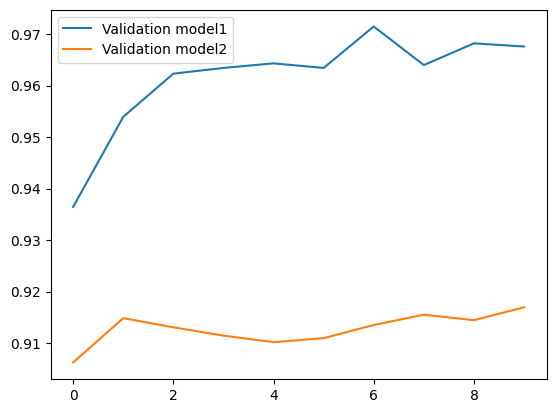

In [51]:
from tensorflow.keras.regularizers import l2

model = Sequential([
    InputLayer(input_shape=(784,)),
    Dense(units=128, activation="relu", kernel_regularizer=l2(l2=1e-3)),
    Dense(units=128, activation="relu", kernel_regularizer=l2(l2=1e-3)),
    Dense(units=10, activation="softmax", kernel_regularizer=l2(l2=1e-3))
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
h = model.fit(x_train, y_train, validation_split=0.3, epochs=10, batch_size=100)

model2 = Sequential([
    InputLayer(input_shape=(784,)),
    Dense(units=128, activation="relu", kernel_regularizer=l2(l2=1e-2)),
    Dense(units=128, activation="relu", kernel_regularizer=l2(l2=1e-2)),
    Dense(units=10, activation="softmax", kernel_regularizer=l2(l2=1e-2))
])

model2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
h2 = model2.fit(x_train, y_train, validation_split=0.3, epochs=10, batch_size=100)

plt.plot(h.history["val_accuracy"], label="Validation model1")
plt.plot(h2.history["val_accuracy"], label="Validation model2")
plt.legend();

**Question #12.** Instead of the $\ell_2$ regularization, set up a [drop-out](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout) strategy and assess its impact on overfitting (you will turn off 10% of the neurons at each training batch).

In [54]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    InputLayer(input_shape=(784,)),
    Dropout(rate=.5),
    Dense(units=128, activation="relu"),
    Dropout(rate=.5),
    Dense(units=128, activation="relu"),
    Dropout(rate=.5),
    Dense(units=10, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
h = model.fit(x_train, y_train, validation_split=0.3, epochs=10, batch_size=100)

Epoch 1/10
420/420 [==============================] - 3s 5ms/step - loss: 1.0355 - accuracy: 0.6532 - val_loss: 0.3398 - val_accuracy: 0.9090
Epoch 2/10
420/420 [==============================] - 2s 5ms/step - loss: 0.5743 - accuracy: 0.8199 - val_loss: 0.2524 - val_accuracy: 0.9306
Epoch 3/10
420/420 [==============================] - 2s 5ms/step - loss: 0.4740 - accuracy: 0.8560 - val_loss: 0.2055 - val_accuracy: 0.9414
Epoch 4/10
420/420 [==============================] - 2s 5ms/step - loss: 0.4301 - accuracy: 0.8716 - val_loss: 0.1836 - val_accuracy: 0.9472
Epoch 5/10
420/420 [==============================] - 2s 5ms/step - loss: 0.3953 - accuracy: 0.8814 - val_loss: 0.1688 - val_accuracy: 0.9499
Epoch 6/10
420/420 [==============================] - 2s 5ms/step - loss: 0.3744 - accuracy: 0.8876 - val_loss: 0.1634 - val_accuracy: 0.9505
Epoch 7/10
420/420 [==============================] - 3s 6ms/step - loss: 0.3517 - accuracy: 0.8948 - val_loss: 0.1533 - val_accuracy: 0.9556
Epoch 

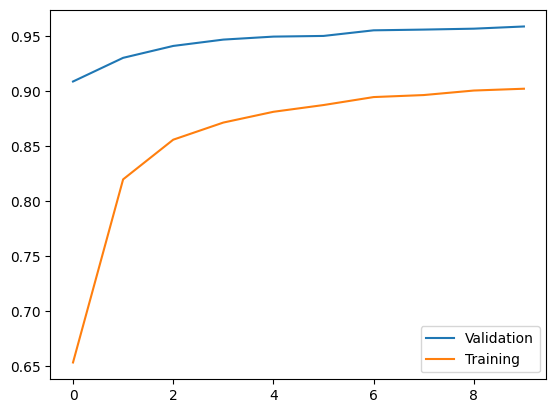

In [55]:
plt.plot(h.history["val_accuracy"], label="Validation")
plt.plot(h.history["accuracy"], label="Training")
plt.legend();

**Question #13.** Set up an [`EarlyStopping`](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping) strategy such that training the model will stop in case the validation loss does not decrease for 5 consecutive epochs.

In [60]:
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    InputLayer(input_shape=(784,)),
    Dense(units=128, activation="relu"),
    Dense(units=128, activation="relu"),
    Dense(units=10, activation="softmax")
])

cb1 = EarlyStopping(
    patience=5,
    monitor="val_accuracy",
    restore_best_weights=True,
    verbose=1
)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.fit(x_train, y_train, validation_split=0.3, epochs=200, batch_size=100, callbacks=[cb1])

Epoch 1/200
420/420 [==============================] - 3s 5ms/step - loss: 0.3445 - accuracy: 0.9011 - val_loss: 0.1861 - val_accuracy: 0.9452
Epoch 2/200
420/420 [==============================] - 2s 4ms/step - loss: 0.1359 - accuracy: 0.9607 - val_loss: 0.1310 - val_accuracy: 0.9609
Epoch 3/200
420/420 [==============================] - 2s 4ms/step - loss: 0.0953 - accuracy: 0.9709 - val_loss: 0.1170 - val_accuracy: 0.9652
Epoch 4/200
420/420 [==============================] - 2s 4ms/step - loss: 0.0702 - accuracy: 0.9793 - val_loss: 0.1065 - val_accuracy: 0.9691
Epoch 5/200
420/420 [==============================] - 2s 4ms/step - loss: 0.0522 - accuracy: 0.9845 - val_loss: 0.1068 - val_accuracy: 0.9668
Epoch 6/200
420/420 [==============================] - 2s 5ms/step - loss: 0.0398 - accuracy: 0.9879 - val_loss: 0.0965 - val_accuracy: 0.9732
Epoch 7/200
420/420 [==============================] - 2s 4ms/step - loss: 0.0316 - accuracy: 0.9903 - val_loss: 0.1138 - val_accuracy: 0.9675

In [62]:
y_pred = model.predict(x_test)
print(y_pred.shape)

313/313 [==============================] - 1s 4ms/step
(10000, 10)


In [63]:
model.evaluate(x_test, y_test)

313/313 [==============================] - 2s 4ms/step - loss: 0.1033 - accuracy: 0.9767


[0.10327663272619247, 0.9767000079154968]